# Bản nộp cuối cùng — Notebook sẵn sàng cho Colab

Notebook này là bản nộp cuối cùng theo yêu cầu sản phẩm. Mục tiêu:

- Hướng dẫn từng bước để thiết lập môi trường, tải dữ liệu công khai, sinh đặc trưng, huấn luyện mô hình và thu thập artifacts để nộp.
- Đảm bảo chạy được trên Google Colab và trên môi trường local (Windows/Linux) mà không phụ thuộc vào việc mount Drive cá nhân.

Lưu ý:
- Không mount Google Drive hoặc các kho lưu trữ cá nhân trong quá trình chạy.
- Trước khi chạy, kiểm tra và đảm bảo bạn đã cung cấp `kaggle.json` (nếu cần tải từ Kaggle).

## 1) Thiết lập dự án

Các bước cơ bản để chuẩn bị môi trường trên Colab hoặc local trước khi chạy các cell tiếp theo.

In [ ]:
import os, subprocess, shutil
from pathlib import Path
import zipfile

# Chỉ clone khi chạy trên Colab; trên local thường không cần clone (đã có source)
try:
    import google.colab  # type: ignore
    from google.colab import files
    IN_COLAB = True
except Exception:
    IN_COLAB = False
    files = None

REPO = "https://github.com/TaikiInomata/ML_Assignment_K22_HCMUT_GROUP_6.git"
CLONE_DIR = "project_folder"

cwd = Path.cwd().resolve()

if IN_COLAB:
    if not os.path.exists(CLONE_DIR):
        print(f"🔄 Đang cố gắng clone từ GitHub: {REPO}")
        try:
            subprocess.run(["git", "clone", REPO, CLONE_DIR], check=True, timeout=60)
            print("✅ Git clone thành công!")
        except Exception as clone_error:
            print(f"⚠️  Git clone thất bại: {clone_error}")
            print("💡 Fallback: Vui lòng upload file project_folder.zip từ máy local")
            print("   Hoặc sử dụng Google Drive để mount dữ liệu")
            
            # Thử upload file zip từ Colab
            if files:
                print("\n📤 Chờ upload file zip chứa project...")
                try:
                    uploaded = files.upload()
                    for filename in uploaded.keys():
                        if filename.endswith('.zip'):
                            print(f"✅ Đã nhận file: {filename}")
                            with zipfile.ZipFile(filename, 'r') as zip_ref:
                                zip_ref.extractall('.')
                            os.remove(filename)
                            
                            # Tìm thư mục được extract
                            for item in os.listdir('.'):
                                if os.path.isdir(item) and item != '__pycache__':
                                    CLONE_DIR = item
                                    break
                            print(f"✅ Đã extract project vào: {CLONE_DIR}")
                        else:
                            print(f"⚠️  File {filename} không phải zip, bỏ qua")
                except Exception as upload_error:
                    print(f"❌ Upload thất bại: {upload_error}")
                    print("⚠️  Vui lòng tải file từ: https://github.com/TaikiInomata/ML_Assignment_K22_HCMUT_GROUP_6")
                    raise RuntimeError("Không thể lấy project files. Vui lòng upload hoặc clone thủ công.")
    
    os.chdir(CLONE_DIR)
    project_root = Path.cwd()
    print("✅ Đang chạy trên Colab. Project root:", project_root.as_posix())
else:
    print("Không chạy trên Colab — bỏ qua bước git clone.")
    # Nếu đang trong thư mục 'notebooks', di chuyển lên project root tự động
    if cwd.name.lower() == "notebooks":
        os.chdir(cwd.parent)
        project_root = Path.cwd()
        print("Đã chuyển thư mục làm việc lên project root:", project_root.as_posix())
    else:
        # Cố gắng tự động tìm project root theo dấu hiệu nếu không ở trong notebooks/
        def find_project_root(start: Path) -> Path:
            markers = ["config.py", "requirements.txt", "scripts", "modules"]
            for p in [start, *start.parents]:
                if all((p / m).exists() for m in markers):
                    return p
            return start
        project_root = find_project_root(cwd)
        os.chdir(project_root)
        print("Working directory hiện tại đã được đặt thành:", project_root.as_posix())

# Đặt biến `project_root` toàn cục để các cell sau dùng chung
globals()["project_root"] = project_root

Không chạy trên Colab — bỏ qua bước git clone.
Đã chuyển thư mục làm việc lên project root: C:/Users/Thanh Dung/Documents/MYDATA/BKU/4/2/ML/BTL/project_folder


In [2]:
from pathlib import Path
import sys
import subprocess

# Xác định project root an toàn (nếu notebook đang ở trong thư mục notebooks/ thì lên 1 cấp)
def find_project_root(start: Path) -> Path:
    markers = ["config.py", "requirements.txt", "scripts", "modules"]
    for p in [start, *start.parents]:
        if all((p / m).exists() for m in markers):
            return p
    return start

cwd = Path.cwd().resolve()
project_root = cwd.parent if cwd.name == "notebooks" else find_project_root(cwd)
req_path = project_root / "requirements.txt"
print("Project root:", project_root.as_posix())

if req_path.exists():
    print("Cài đặt từ:", req_path)
    try:
        subprocess.run([sys.executable, "-m", "pip", "install", "-r", str(req_path)], check=True)
    except subprocess.CalledProcessError as e:
        print("Lỗi khi cài từ requirements.txt:", e)
        # Thử file thay thế đã tạo bởi workflow (không gồm TensorFlow và gói jupyter nặng)
        alt = project_root / 'requirements-no-tf-no-jupyter.txt'
        if alt.exists():
            print("Thử cài các phụ thuộc không gồm TensorFlow/Jupyter từ:", alt.as_posix())
            subprocess.run([sys.executable, "-m", "pip", "install", "-r", str(alt)], check=True)
        else:
            print("Không tìm thấy file thay thế. Gợi ý:")
            print(" - Bật Windows Long Path nếu gặp lỗi đường dẫn dài (pip warning).")
            print(" - Tạo file 'requirements-no-tf-no-jupyter.txt' hoặc cài tay các gói cần thiết.")
else:
    print("Không tìm thấy requirements.txt tại:", req_path.as_posix())
    print("Bạn có thể tạo file requirements.txt tại project root hoặc cài thủ công các thư viện cần thiết.")

Project root: C:/Users/Thanh Dung/Documents/MYDATA/BKU/4/2/ML/BTL/project_folder
Cài đặt từ: C:\Users\Thanh Dung\Documents\MYDATA\BKU\4\2\ML\BTL\project_folder\requirements.txt
Lỗi khi cài từ requirements.txt: Command '['c:\\Users\\Thanh Dung\\Documents\\MYDATA\\BKU\\4\\2\\ML\\BTL\\project_folder\\.venv\\Scripts\\python.exe', '-m', 'pip', 'install', '-r', 'C:\\Users\\Thanh Dung\\Documents\\MYDATA\\BKU\\4\\2\\ML\\BTL\\project_folder\\requirements.txt']' returned non-zero exit status 1.
Thử cài các phụ thuộc không gồm TensorFlow/Jupyter từ: C:/Users/Thanh Dung/Documents/MYDATA/BKU/4/2/ML/BTL/project_folder/requirements-no-tf-no-jupyter.txt


## 2) Khai báo nguồn dữ liệu công khai

Xác định nguồn dữ liệu công khai (ví dụ Kaggle). Cell tiếp theo hiển thị đường dẫn nguồn công khai để tham khảo.

In [3]:
PUBLIC_DATA_SOURCE = "https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand"
print("Public data source:", PUBLIC_DATA_SOURCE)

Public data source: https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand


## 3) Tải dữ liệu (Kaggle API)

Hướng dẫn tải dữ liệu từ nguồn công khai (Kaggle). Notebook sẽ cố gắng dùng `kaggle.json` từ môi trường, cho phép upload từ Colab, hoặc sử dụng file dự phòng trong project.

In [4]:
import glob
import os
import shutil
import stat
import subprocess
import zipfile
from pathlib import Path

def find_project_root(start: Path) -> Path:
    markers = ["config.py", "requirements.txt", "scripts", "modules"]
    for p in [start, *start.parents]:
        if all((p / m).exists() for m in markers):
            return p
    return start

project_root = find_project_root(Path.cwd().resolve())
data_dir = project_root / "data"
data_dir.mkdir(parents=True, exist_ok=True)
dataset_csv = data_dir / "hotel_bookings.csv"
print("project_root:", project_root.as_posix())

# 0) Neu da co san file du lieu thi bo qua buoc download Kaggle
if dataset_csv.exists():
    print(f"[Skip] Da tim thay du lieu san co: {dataset_csv.as_posix()}")
else:
    # 1) Cai kaggle CLI
    subprocess.run(["python", "-m", "pip", "install", "-q", "kaggle"], check=True)

    # 2) Chuan bi thu muc ~/.kaggle
    kaggle_dir = Path.home() / ".kaggle"
    kaggle_dir.mkdir(parents=True, exist_ok=True)
    kaggle_json = kaggle_dir / "kaggle.json"

    # 3) Neu co bien moi truong KAGGLE_USERNAME/KAGGLE_KEY thi tao kaggle.json
    kaggle_user = os.getenv("KAGGLE_USERNAME")
    kaggle_key = os.getenv("KAGGLE_KEY")
    if (not kaggle_json.exists()) and kaggle_user and kaggle_key:
        kaggle_json.write_text(
            '{\n  "username": "' + kaggle_user + '",\n  "key": "' + kaggle_key + '"\n}',
            encoding="utf-8",
        )

    # 4) Neu dang chay tren Colab thi cho upload kaggle.json
    if not kaggle_json.exists():
        try:
            from google.colab import files  # type: ignore

            print("[Info] Colab mode: vui long upload kaggle.json")
            uploaded = files.upload()
            if "kaggle.json" in uploaded:
                with open(kaggle_json, "wb") as f:
                    f.write(uploaded["kaggle.json"])
        except ModuleNotFoundError:
            pass

    # 5) Fallback local: tim kaggle.json o mot so vi tri thong dung
    if not kaggle_json.exists():
        candidates = [
            project_root / "kaggle.json",
            project_root / "data" / "kaggle.json",
            project_root / ".kaggle" / "kaggle.json",
            Path.cwd() / "kaggle.json",
            Path.cwd() / "data" / "kaggle.json",
            Path.cwd() / ".kaggle" / "kaggle.json",
        ]
        for c in candidates:
            if c.exists():
                shutil.copy2(c, kaggle_json)
                break

    # 6) Kiem tra kaggle.json bat buoc phai ton tai
    if not kaggle_json.exists():
        raise FileNotFoundError(
            "Khong tim thay ~/.kaggle/kaggle.json va cung chua co data/hotel_bookings.csv. "
            "Hay lam 1 trong 4 cach: "
            "(1) dat file kaggle.json vao ~/.kaggle/, "
            "(2) dat kaggle.json trong thu muc project, "
            "(3) set bien moi truong KAGGLE_USERNAME va KAGGLE_KEY, "
            "(4) dat san data/hotel_bookings.csv vao thu muc data/."
        )

    # 7) Dat quyen doc token an toan (bo qua neu he dieu hanh khong ho tro)
    try:
        kaggle_json.chmod(stat.S_IRUSR | stat.S_IWUSR)
    except Exception:
        pass

    # 8) Download dataset
    subprocess.run(
        [
            "kaggle",
            "datasets",
            "download",
            "-d",
            "jessemostipak/hotel-booking-demand",
            "-p",
            str(data_dir),
            "--force",
        ],
        check=True,
    )

    # 9) Giai nen
    for z in glob.glob(str(data_dir / "*.zip")):
        with zipfile.ZipFile(z, "r") as f:
            f.extractall(str(data_dir))

print("Files in data/:")
for p in sorted(data_dir.glob("*")):
    print("-", p.as_posix())

project_root: C:/Users/Thanh Dung/Documents/MYDATA/BKU/4/2/ML/BTL/project_folder
[Skip] Da tim thay du lieu san co: C:/Users/Thanh Dung/Documents/MYDATA/BKU/4/2/ML/BTL/project_folder/data/hotel_bookings.csv
Files in data/:
- C:/Users/Thanh Dung/Documents/MYDATA/BKU/4/2/ML/BTL/project_folder/data/.gitkeep
- C:/Users/Thanh Dung/Documents/MYDATA/BKU/4/2/ML/BTL/project_folder/data/hotel_bookings.csv
- C:/Users/Thanh Dung/Documents/MYDATA/BKU/4/2/ML/BTL/project_folder/data/processed
- C:/Users/Thanh Dung/Documents/MYDATA/BKU/4/2/ML/BTL/project_folder/data/README.md


## 4) Kiểm tra đầu vào

Xác nhận file dữ liệu đã có trong thư mục `data/` trước khi thực hiện các bước xử lý tiếp theo.

In [5]:
from pathlib import Path

# Dung duong dan theo project_root neu da co tu Cell 8, neu khong thi tu dong suy ra
if "project_root" not in globals():
    def find_project_root(start: Path) -> Path:
        markers = ["config.py", "requirements.txt", "scripts", "modules"]
        for p in [start, *start.parents]:
            if all((p / m).exists() for m in markers):
                return p
        return start

    project_root = find_project_root(Path.cwd().resolve())

p = Path(project_root) / "data" / "hotel_bookings.csv"
assert p.exists(), f"Khong tim thay {p.as_posix()}"
print("OK:", p.as_posix(), "size=", p.stat().st_size)

OK: C:/Users/Thanh Dung/Documents/MYDATA/BKU/4/2/ML/BTL/project_folder/data/hotel_bookings.csv size= 16974990


## 5) Chạy pipeline mô hình

Thực thi script huấn luyện mô hình. Bạn có thể chuyển tham số `--quick` thành `--full` để chạy đầy đủ (thời gian thực thi lâu hơn).

In [ ]:
from pathlib import Path
import os

# Kiểm tra file script tồn tại
script_file = Path.cwd() / "scripts" / "run_stage3_svm.py"
print("Current working directory:", Path.cwd().as_posix())
print("Looking for script at:", script_file.as_posix())

if not script_file.exists():
    print("❌ Script file not found! Checking alternatives...")
    
    # Tìm trong parent directories
    found = False
    for parent in [Path.cwd(), *Path.cwd().parents]:
        alt = parent / "scripts" / "run_stage3_svm.py"
        if alt.exists():
            print(f"✅ Found at: {alt.as_posix()}")
            os.chdir(parent)
            print(f"Changed working directory to: {Path.cwd().as_posix()}")
            found = True
            break
    
    if not found:
        raise FileNotFoundError(
            f"Cannot find run_stage3_svm.py in any scripts/ directory. "
            f"Current directory: {Path.cwd().as_posix()}"
        )

# Xác nhận file tồn tại
script_check = Path.cwd() / "scripts" / "run_stage3_svm.py"
assert script_check.exists(), f"Script still not found at {script_check.as_posix()}"
print(f"✅ Script verified at: {script_check.as_posix()}")
print(f"✅ Ready to execute: python scripts/run_stage3_svm.py")

In [7]:
!python scripts/run_stage3_svm.py --quick --cv 2 --max-iter 3000

[Stage3-Member3] Load dataset...
[Data Loader] Đọc dữ liệu thành công - shape: (119390, 32)
[Stage3-Member3] Preprocess với train/test split...
[Preprocessing] Bắt đầu preprocessing với train/test split (tránh data leakage)...
[Preprocessing] Split data: 80% train, 20% test
  - Train shape: (95512, 31), Test shape: (23878, 31)

--- BƯỚC 1: XỬ LÝ MISSING DATA - IMPUTATION ---
[Preprocessing] Đã xoá các cột: ['company', 'reservation_status', 'reservation_status_date']
[Preprocessing] Điền giá trị 0.0 cho cột 'agent'
[Preprocessing] Fitting SimpleImputer (strategy='median') trên train data...

--- BƯỚC 2: ENCODING ---
[Preprocessing] Fitting OneHot encoding trên train data...
[Preprocessing] OneHot encoding xong. Features: 252

--- BƯỚC 3: SCALING ---
[Preprocessing] Fitting StandardScaler trên train data...
[Preprocessing] Scaling xong cho 252 features

[Preprocessing] Hoàn tất preprocessing! Train: (95512, 252), Test: (23878, 252)
[Stage3-Member3] Downsample train set cho GridSearchCV: 

c:\Users\Thanh Dung\Documents\MYDATA\BKU\4\2\ML\BTL\project_folder\.venv\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=3000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Thanh Dung\Documents\MYDATA\BKU\4\2\ML\BTL\project_folder\.venv\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=3000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Thanh Dung\Documents\MYDATA\BKU\4\2\ML\BTL\project_folder\.venv\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=3000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
C:\Users\Thanh Dung\Documents\MYDATA\BKU\4\2\ML\BTL\project_folder\scripts\run_stage3_svm.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.

## 6) Tạo và lưu file đặc trưng (.npy / .h5)

Chạy pipeline tiền xử lý và tạo đặc trưng, sau đó lưu các file đặc trưng ở định dạng `.npy` hoặc `.h5` để dùng cho bước huấn luyện và đánh giá.

In [8]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

def find_project_root(start: Path) -> Path:
    markers = ["config.py", "requirements.txt", "scripts", "modules"]
    for p in [start, *start.parents]:
        if all((p / m).exists() for m in markers):
            return p
    return start

project_root = find_project_root(Path.cwd().resolve())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from config import CONFIG
from modules.preprocessing import preprocess_with_train_test_split
from modules.features import engineer_features, save_features

data_path = Path(project_root) / "data" / "hotel_bookings.csv"
_df = pd.read_csv(data_path)

X_train, X_test, y_train, y_test, _ = preprocess_with_train_test_split(
    df=_df,
    target_column=CONFIG['data']['target_column'],
    config=CONFIG['preprocessing'],
    test_size=CONFIG['models']['train_test_split']['test_size'],
    random_state=CONFIG['models']['train_test_split']['random_state'],
)

X_train_eng, feat_meta = engineer_features(X_train, CONFIG['features'])

out_cfg = dict(CONFIG['features']['output'])
out_cfg['format'] = 'npy'  # doi thanh 'h5' neu can
out_cfg['path'] = str(Path(project_root) / 'features' / 'final_submission_features')
save_path = save_features(X_train_eng, np.asarray(y_train), out_cfg)
print('Saved features at:', save_path)
print('Feature metadata keys:', feat_meta.keys())

[Preprocessing] Bắt đầu preprocessing với train/test split (tránh data leakage)...
[Preprocessing] Split data: 80% train, 20% test
  - Train shape: (95512, 31), Test shape: (23878, 31)

--- BƯỚC 1: XỬ LÝ MISSING DATA - IMPUTATION ---
[Preprocessing] Đã xoá các cột: ['company', 'reservation_status', 'reservation_status_date']
[Preprocessing] Điền giá trị 0.0 cho cột 'agent'
[Preprocessing] Fitting SimpleImputer (strategy='median') trên train data...

--- BƯỚC 2: ENCODING ---
[Preprocessing] Fitting OneHot encoding trên train data...
[Preprocessing] OneHot encoding xong. Features: 252

--- BƯỚC 3: SCALING ---
[Preprocessing] Fitting StandardScaler trên train data...
[Preprocessing] Scaling xong cho 252 features

[Preprocessing] Hoàn tất preprocessing! Train: (95512, 252), Test: (23878, 252)
[Features] Chạy feature engineering pipeline
[Features] Áp dụng PCA với variance_threshold=0.95
[Features] PCA hoàn tất: 252 → 214 components
[Features] Tổng explained variance: 0.9533
[Features] Đã l

[Stage3-Member3] Load dataset...
[Data Loader] Đọc dữ liệu thành công - shape: (119390, 32)
[Stage3-Member3] Preprocess với train/test split...
[Preprocessing] Bắt đầu preprocessing với train/test split (tránh data leakage)...
[Preprocessing] Split data: 80% train, 20% test
  - Train shape: (95512, 31), Test shape: (23878, 31)

--- BƯỚC 1: XỬ LÝ MISSING DATA - IMPUTATION ---
[Preprocessing] Đã xoá các cột: ['company', 'reservation_status', 'reservation_status_date']
[Preprocessing] Điền giá trị 0.0 cho cột 'agent'
[Preprocessing] Fitting SimpleImputer (strategy='median') trên train data...

--- BƯỚC 2: ENCODING ---
[Preprocessing] Fitting OneHot encoding trên train data...
[Preprocessing] OneHot encoding xong. Features: 252

--- BƯỚC 3: SCALING ---
[Preprocessing] Fitting StandardScaler trên train data...
[Preprocessing] Scaling xong cho 252 features

[Preprocessing] Hoàn tất preprocessing! Train: (95512, 252), Test: (23878, 252)
[Stage3-Member3] Downsample train set cho GridSearchCV: 

c:\Users\Thanh Dung\Documents\MYDATA\BKU\4\2\ML\BTL\project_folder\.venv\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Thanh Dung\Documents\MYDATA\BKU\4\2\ML\BTL\project_folder\.venv\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Thanh Dung\Documents\MYDATA\BKU\4\2\ML\BTL\project_folder\.venv\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Thanh Dung\Documents\MYDATA\BKU\4\2\ML\BTL\project_folder\.venv\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-pro

## 7) Tổng hợp kết quả

Liệt kê các artifacts (mô hình, metrics, đặc trưng) đã sinh để thuận tiện cho việc nộp bài.

In [ ]:
from pathlib import Path

# Dung project_root neu da co tu cac cell truoc, neu khong thi fallback cwd
root = Path(project_root) if "project_root" in globals() else Path.cwd()

for rel in ["reports/evaluation", "features"]:
    folder = root / rel
    print(f"\n== {folder.as_posix()} ==")
    if not folder.exists():
        print("[Missing] Folder khong ton tai")
        continue
    for p in sorted(folder.glob("*")):
        kind = "dir" if p.is_dir() else "file"
        size = "-" if p.is_dir() else str(p.stat().st_size)
        print(f"- {p.name} | {kind} | size={size}")


== C:/Users/Thanh Dung/Documents/MYDATA/BKU/4/2/ML/BTL/project_folder/reports/evaluation ==
- .gitkeep | file | size=0
- logistic_regression_confusion_matrix.png | file | size=17484
- logistic_regression_fast_confusion_matrix.png | file | size=53207
- logistic_regression_fast_roc_auc.png | file | size=130852
- logistic_regression_pr.png | file | size=24386
- logistic_regression_roc.png | file | size=25968
- logistic_regression_roc_auc.png | file | size=137003
- lr_top_coefficients.png | file | size=17868
- mlp_confusion_matrix.png | file | size=16537
- mlp_pr.png | file | size=21387
- mlp_roc.png | file | size=23805
- mlp_roc_auc.png | file | size=133875
- model_comparison.png | file | size=113161
- model_comparison_fast.png | file | size=104136
- model_comparison_scores.png | file | size=21700
- pca_scatter_train.png | file | size=66186
- random_forest_confusion_matrix.png | file | size=17083
- random_forest_fast_confusion_matrix.png | file | size=51913
- random_forest_fast_roc_auc.p

## 8) Tự kiểm tra trước khi nộp

Danh sách kiểm tra cơ bản trước khi nộp:

- Đảm bảo tồn tại các thư mục và file cần thiết (`notebooks/`, `modules/`, `reports/`, `features/`).
- Có ít nhất một file `.npy` hoặc `.h5` trong `features/` chứa đặc trưng.
- File `reports/evaluation/svm_test_metrics.json` hoặc các báo cáo đánh giá khác tồn tại.

In [ ]:
from pathlib import Path

# Dung project_root neu da co, neu khong thi tu suy ra
if "project_root" not in globals():
    def find_project_root(start: Path) -> Path:
        markers = ["config.py", "requirements.txt", "scripts", "modules"]
        for p in [start, *start.parents]:
            if all((p / m).exists() for m in markers):
                return p
        return start

    project_root = find_project_root(Path.cwd().resolve())

root = Path(project_root)
required_paths = [
    root / "notebooks",
    root / "modules",
    root / "reports",
    root / "features",
    root / "reports" / "evaluation" / "svm_test_metrics.json",
]

missing = [x.as_posix() for x in required_paths if not x.exists()]
if missing:
    raise FileNotFoundError("Thieu cac muc bat buoc: " + ", ".join(missing))

has_npy = any((root / "features").glob("*.npy"))
has_h5 = any((root / "features").glob("*.h5"))
assert (has_npy or has_h5), "Can co it nhat 1 file .npy hoac .h5 trong features/"

print("Checklist co ban: PASS")
print("project_root:", root.as_posix())

Checklist co ban: PASS
project_root: C:/Users/Thanh Dung/Documents/MYDATA/BKU/4/2/ML/BTL/project_folder


## 9. Trước khi nộp sản phẩm

Hướng dẫn cuối cùng trước khi nộp:

- Chạy `Runtime -> Run all` (Colab) hoặc chạy tuần tự các cell trên môi trường local.
- Xác nhận không gắn mount tới kho lưu trữ cá nhân (Drive, Dropbox, v.v.).
- Kiểm tra đầy đủ artifacts trong `features/` và `reports/` (EDA, mô hình, metrics).
- Bổ sung liên kết Colab, file PDF báo cáo và hướng dẫn chạy vào `README.md` trước khi nộp.

## Visualizations — Tóm tắt biểu đồ

Các biểu đồ (confusion matrix, ROC, Precision-Recall, so sánh mô hình, feature importance, PCA scatter) được sinh và lưu trong thư mục `reports/evaluation/`. Cell dưới đây hiển thị một số ảnh để kiểm tra nhanh.

Found 26 visualizations in C:\Users\Thanh Dung\Documents\MYDATA\BKU\4\2\ML\BTL\project_folder\reports\evaluation


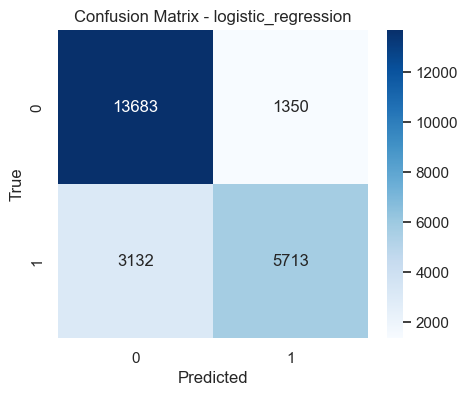

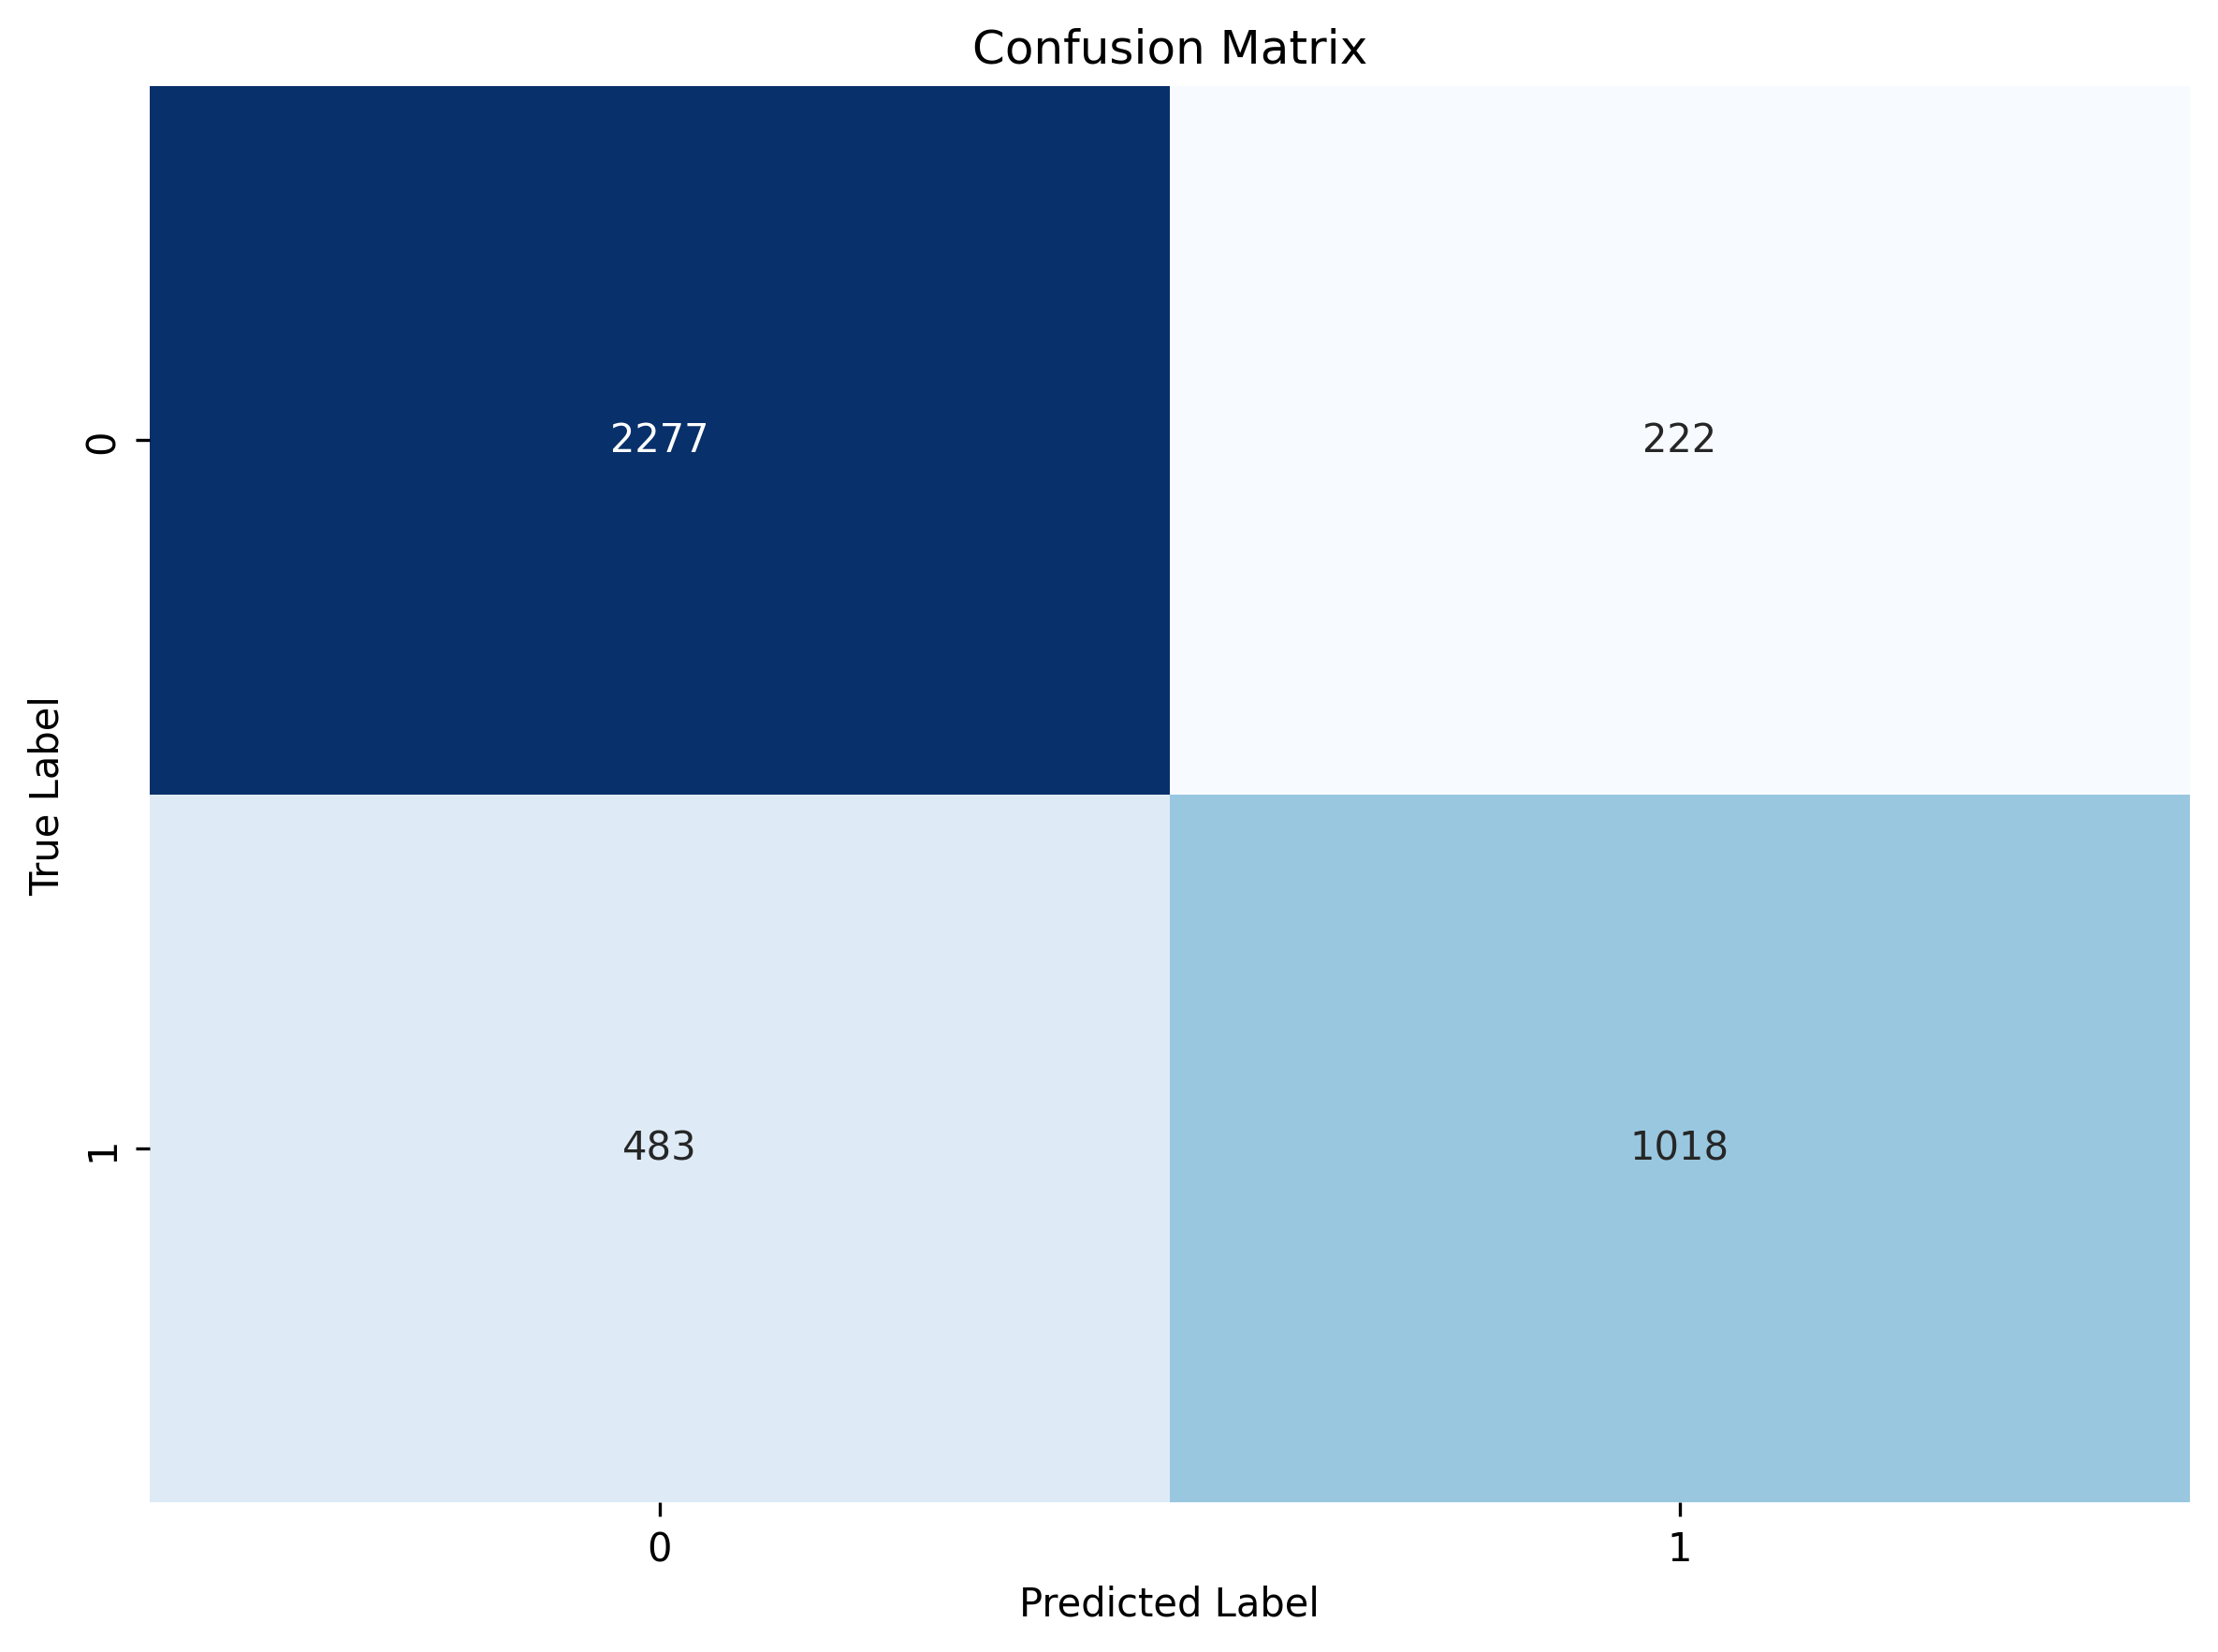

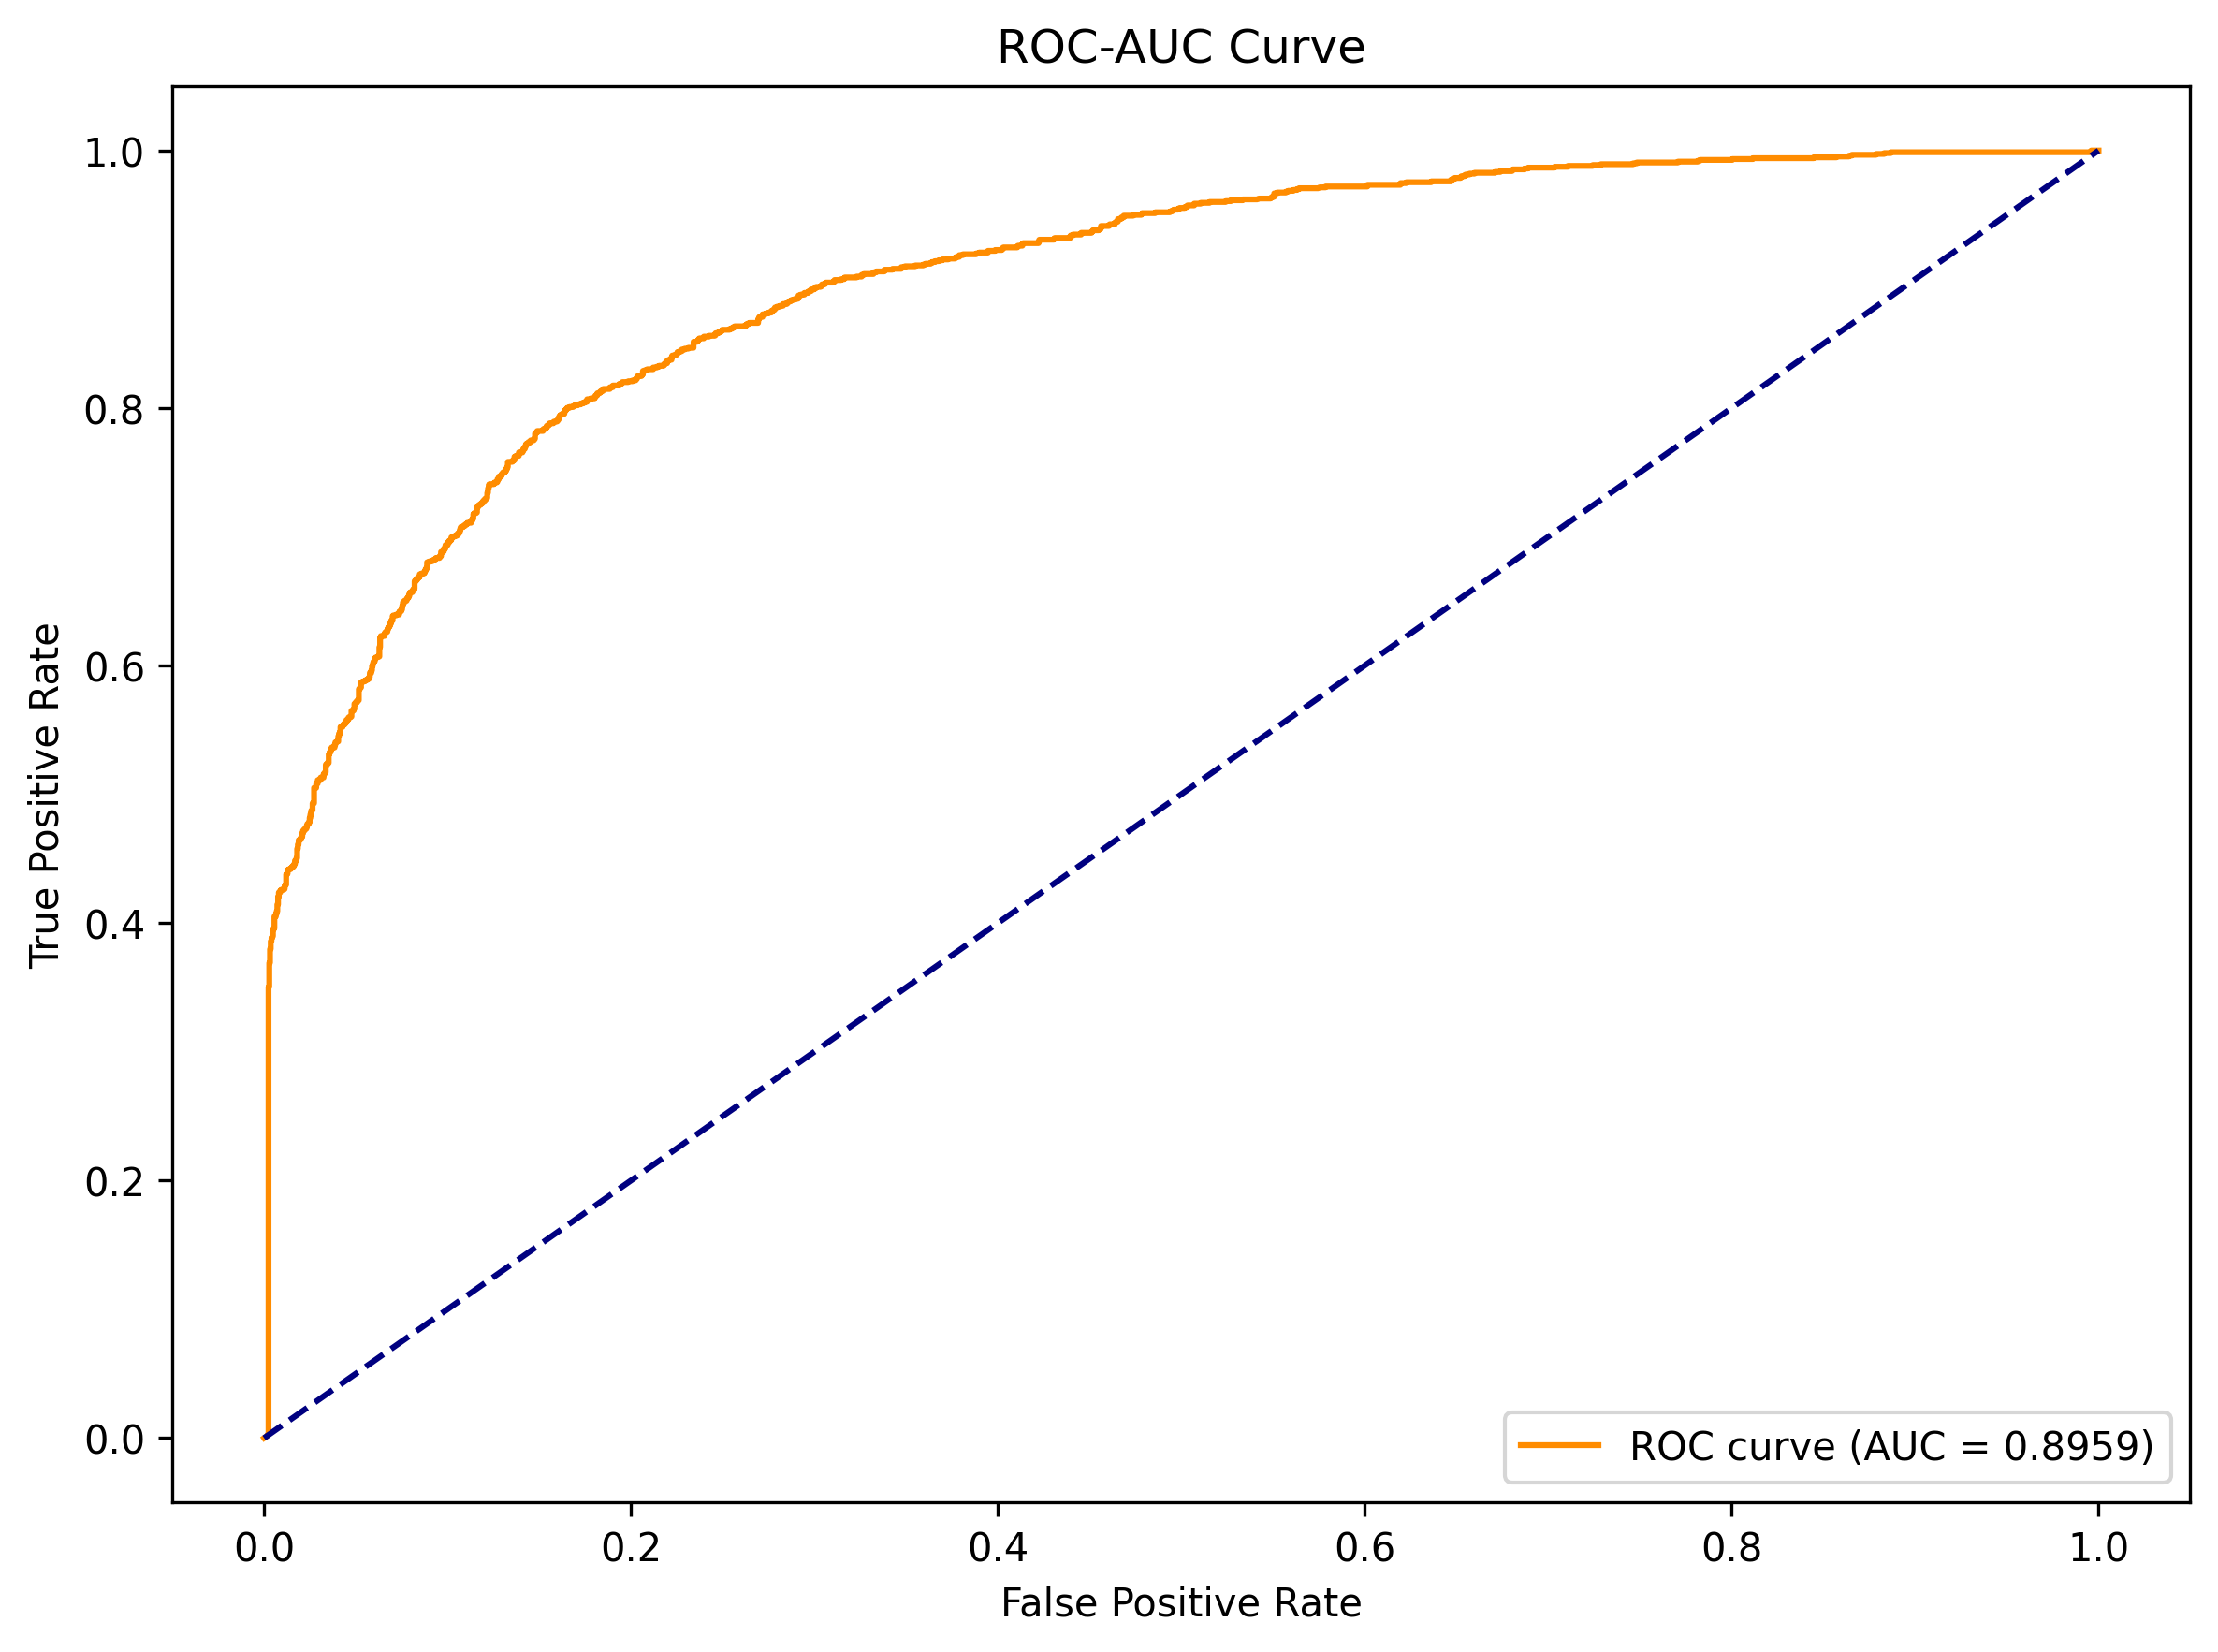

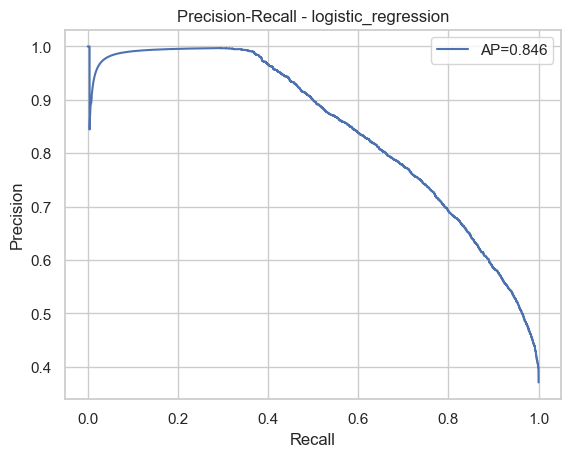

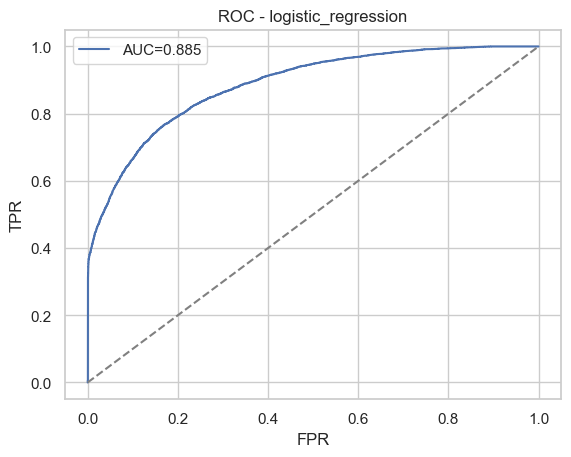

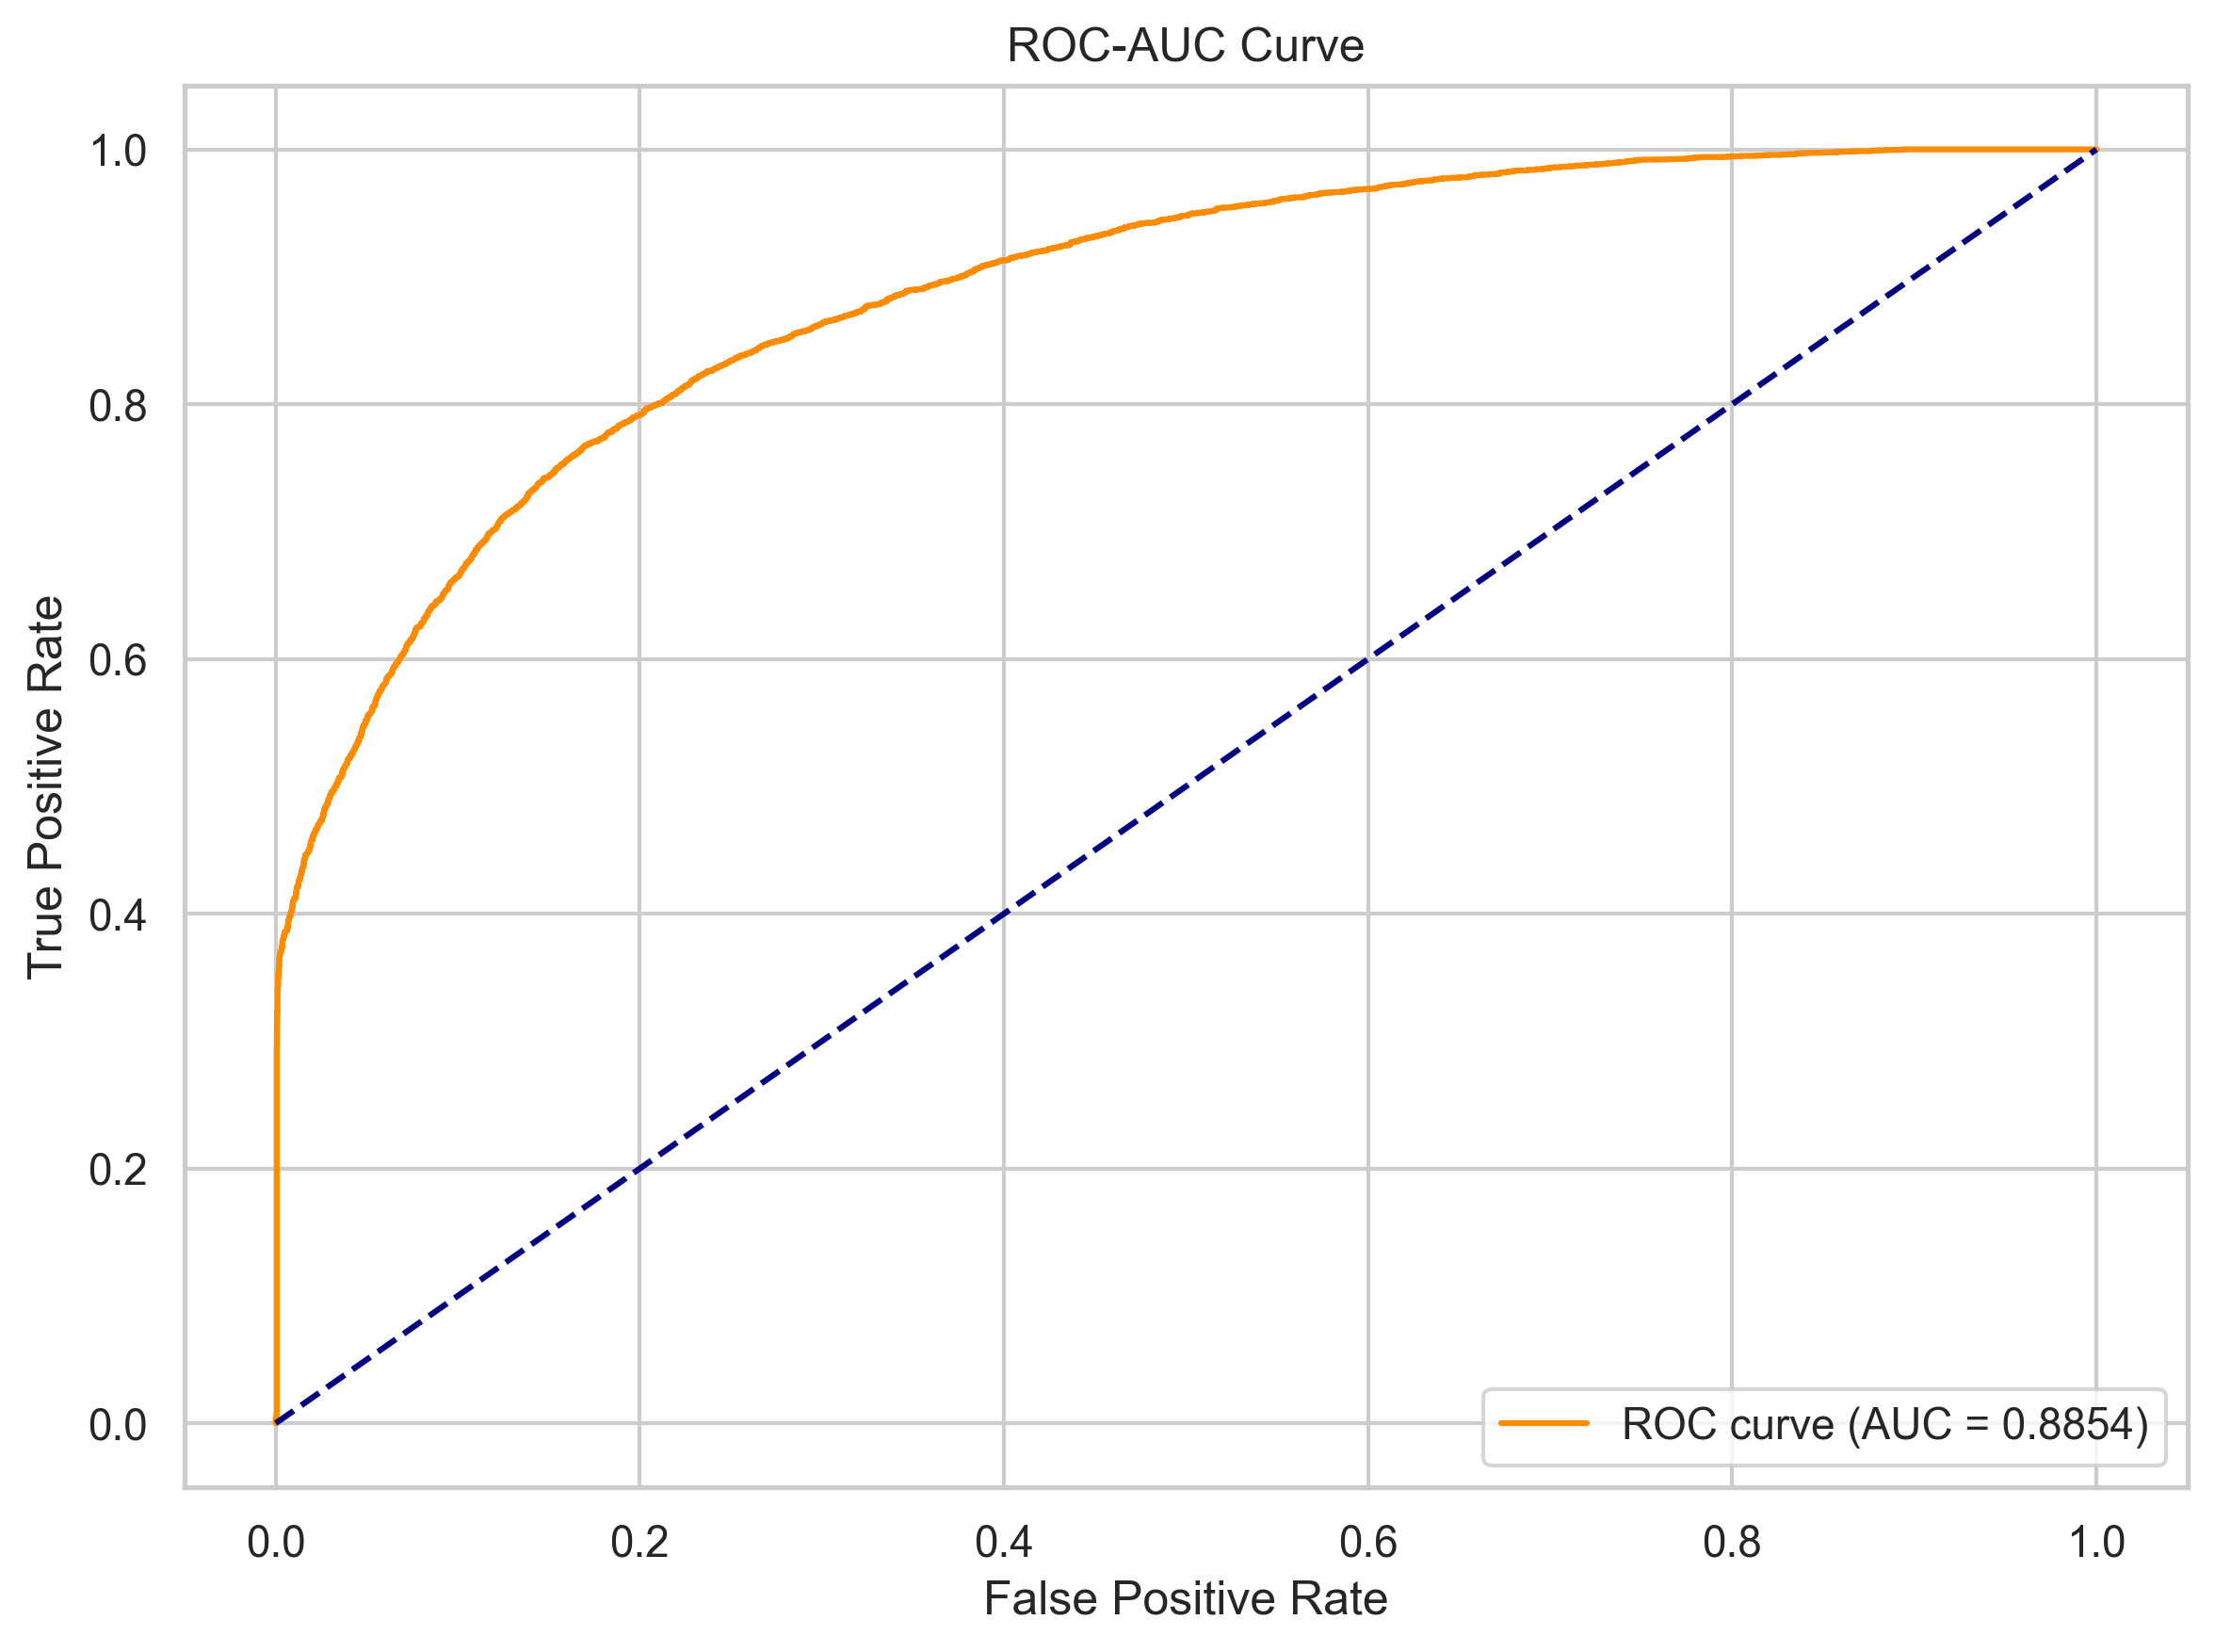

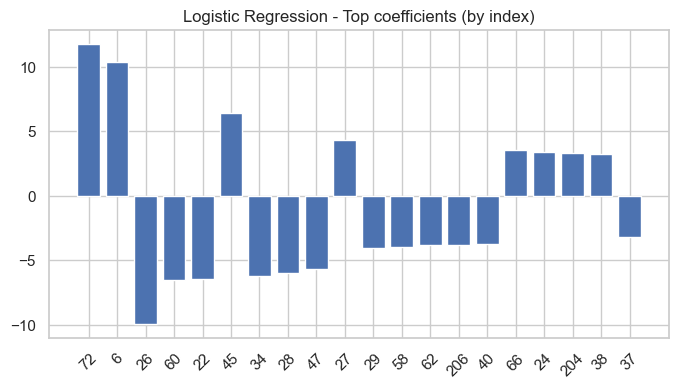

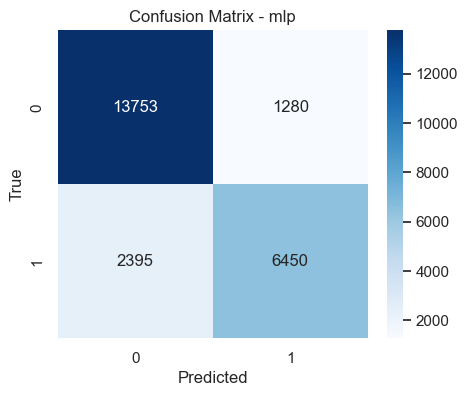

In [ ]:
from pathlib import Path
from IPython.display import Image, display

eval_dir = Path(project_root) / CONFIG['evaluation']['output_dir']
imgs = sorted(eval_dir.glob('*.png')) if eval_dir.exists() else []
print('Found', len(imgs), 'visualizations in', eval_dir)
for p in imgs[:8]:
    display(Image(str(p)))